### 使用卷积神经网络进行图像分类

In [3]:
import torch
in_channels, out_channels= 5, 10
width, height = 100, 100  
kernel_size = 3  
batch_size = 1

input = torch.randn(batch_size, in_channels,  width,  height)
conv_layer = torch.nn.Conv2d(in_channels,
out_channels,
kernel_size=kernel_size)
output = conv_layer(input)  
print(input.shape)
print(output.shape)
print(conv_layer.weight.shape)

torch.Size([1, 5, 100, 100])
torch.Size([1, 10, 98, 98])
torch.Size([10, 5, 3, 3])


In [5]:
import torch

input = [3,4,6,5,7,
2,4,6,8,2,
1,6,7,8,4,
9,7,4,6,2,
3,7,5,4,1]
input = torch.Tensor(input).view(1, 1, 5, 5)

conv_layer = torch.nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
kernel = torch.Tensor([1,2,3,4,5,6,7,8,9]).view(1, 1, 3, 3)
conv_layer.weight.data = kernel.data
output = conv_layer(input)
print(output.shape)      


torch.Size([1, 1, 5, 5])


<img src=".\\img\\cifar10.png">cifar10</img>

* <font color='red'>CIFAR-10数据集</font>：样本是32x32的彩色图片，10个类别。PyTorch有现成的数据集，方便加载。
* <font color='red'>数据预处理</font>：需要做归一化，比如用均值和标准差来标准化；数据增强，比如随机水平翻转、随机裁剪之类的，这样可以提升模型泛化能力。
* <font color='red'>数据加载</font>：DataLoader的设置，batch size通常选128或者256，根据显存情况调整。
* <font color='red'>模型结构</font>: CIFAR-10的图片比较小，用深层的CNN可能容易过拟合。需要设计一个合适的架构：比如经典的几个卷积层，加上池化，然后全连接层。可参考一些经典模型，比如VGG、ResNet之类的简化版。或者自己设计一个较小的网络，避免参数过多。
* <font color='red'>激活函数</font>：ReLU比较常用，可以防止梯度消失。批量归一化（BatchNorm）也应该加上，这样训练更稳定，收敛更快。Dropout层在全连接层使用，防止过拟合。
* <font color='red'>损失函数：用交叉熵，优化器用SGD或者Adam。学习率可能需要调整，或者用学习率调度器，比如StepLR或者CosineAnnealing。
* <font color='red'>循环训练</font>：需要迭代多个epoch，每个epoch里遍历训练集，前向传播，计算loss，反向传播，优化参数。然后每个epoch结束后在测试集上验证准确率。

In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

# 数据预处理
transform_train = transforms.Compose([
    # 数据增强：随机裁剪，在图像周围填充可防止在随机裁剪时丢失图像边缘的重要信息
    transforms.RandomCrop(32, padding=4),  
    transforms.RandomHorizontalFlip(),      # 数据增强：水平翻转
    transforms.ToTensor(),
    #将图像的每个通道进行标准化，参数一为每个通道的均值，参数二为每个通道的std
    #每个通道归一化的计算公式：(value-mean)/std，(-1,1)
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # 标准化
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 加载数据集
train_set = torchvision.datasets.CIFAR10(root='.//data', train=True, download=False, transform=transform_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='.//data', train=False, download=False, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, num_workers=2)


In [2]:
# 定义CNN模型
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # 卷积层1: 3@32x32 -> 64@32x32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  # 批标准化
            nn.ReLU(inplace=True),
            # 卷积层2: 64@32x32 -> 64@32x32
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 输出64@16x16
            # 卷积层3: 64@16x16 -> 128@16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),      
            # 卷积层4: 128@16x16 -> 128@16x16
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 输出128@8x8
        )    
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),  # 防止过拟合
            nn.Linear(128*8*8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # 展平
        x = self.classifier(x)
        return x


### <font color='red'>BatchNorm2d</font>：
* 在卷积神经网络（CNN）中广泛应用，特别是在处理大规模图像数据时效果显著。它可以加快模型的收敛速度，减少模型对初始化的敏感性，并且在一定程度上能够防止模型过拟合。
### <font color='red'>LayerNorm</font>：
* 通常用于对单个样本的所有特征维度进行归一化。例如，对于一个形状为
(N,C,H,W)的输入，它会计算每个样本的C×H×W个元素的均值和方差，然后对该样本的所有元素进行归一化。
* 在自然语言处理（NLP）领域中应用较多，例如在循环神经网络（RNN）、长短时记忆网络（LSTM）和 Transformer 等模型中。
* 在 NLP 任务中，每个样本的长度可能不同，使用BatchNorm2d会受到批次内样本长度不一致的影响，而LayerNorm针对单个样本进行归一化，不受样本长度的限制，更适合处理这种序列数据。

In [3]:
# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # 使用Adam优化器
#torch.optim.lr_scheduler.StepLR是 PyTorch 中用于调整学习率的调度器。
#它会按照指定的步数周期性地调整学习率。
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # 学习率衰减

### <font color='red'>nn.CrossEntropyLoss()</font>：
* 主要<font color='blue'>用于分类任务</font>。
* 在图像分类中，判断一张图片属于猫、狗、兔子等不同类别；
* 在文本分类中，确定一段文本属于情感积极、消极或中性等类别。
* 它通过计算<font color='blue'>预测的类别分布与真实类别分布之间的差异</font>来衡量模型的性能，能很好地反映分类模型在不同类别上的预测准确性。
* 包含了 Softmax 操作,将nn.LogSoftmax()和nn.NLLLoss()（负对数似然损失）结合在一起，在计算损失时，会先对输入数据进行 Softmax 操作，将其转换为概率分布，然后再计算交叉熵损失
* 这样在使用nn.CrossEntropyLoss()时，模型的最后一层不需要再添加 Softmax 可。
### <font color='red'>nn.MSE()</font>：
* 通常<font color='blue'>用于回归任务</font>。
* 预测房价、股票价格、温度等连续数值型数据。它计算的是<font color='blue'>预测值与真实值之间的平均平方误差</font>，侧重于衡量预测值与真实值在数值上的接近程度。

<font color='red'>Adam算法</font>:
* 结合了 Adagrad 和 RMSProp 算法的优点，不仅可以自适应地调整每个参数的学习率，还能处理非平稳目标函数和稀疏梯度问题。
* weight_decay（权重衰减）参数是用于防止模型过拟合的一个超参数。

### <font color='red'>torch.optim.lr_scheduler.StepLR</font>是 PyTorch 中用于调整学习率的调度器。
*  <font color='red'>optimizer</font>：要调整学习率的优化器对象，例如Adam、SGD等优化器实例。
*  <font color='red'>step_size</font>：学习率下降的步长。这里设置为10，表示每隔10个训练周期（epochs），学习率就会调整一次。
*  <font color='red'>gamma</font>：学习率的衰减因子。这里设为0.1，意味着每次调整时，学习率会乘以0.1，即学习率会变为原来的十分之一。

### <font color='red'>torch.optim.lr_scheduler.ReduceLROnPlateau</font>
* 用于在指标（如验证集损失）不再改善时降低学习率。
* patience参数表示在学习率降低之前，允许指标没有改善的连续训练周期数。

In [13]:
# 训练函数
def train(epoch):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        # 前向传播
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        # 反向传播
        loss.backward()
        optimizer.step()
        # 统计指标
        train_loss += loss.item()      # 累加损失
        _, predicted = outputs.max(1) # 获取预测结果
        total += targets.size(0)      # 累加batch大小
        correct += predicted.eq(targets).sum().item()   # 统计正确数
        # 每100个batch打印进度
        if batch_idx % 100 == 99:
            print(f'Epoch: {epoch+1} | Batch: {batch_idx+1} | Loss: {loss.item():.3f}')
        
    # 计算epoch指标
    epoch_loss = train_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f'Epoch: {epoch+1} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%')
    return epoch_loss, epoch_acc
        
# 测试函数
def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1) # 获取预测结果
            total += targets.size(0)  # 累加batch大小
            correct += predicted.eq(targets).sum().item()
    return 100.0 * correct / total

In [14]:
#可视化设置：
# 初始化2个列表存储训练过程中的指标
train_losses = []  # 记录每个epoch的训练损失
train_accuracies = []  # 记录训练准确率
# 训练循环
for epoch in range(6):
    train_loss, train_acc = train(epoch)
    train_losses.append(train_loss)  # 添加训练损失到列表
    train_accuracies.append(train_acc)  # 添加训练准确率
    test()
    print(f"Epoch {epoch+1}, Test Acc: {acc:.2f}%")
    scheduler.step()

Epoch: 1 | Batch: 100 | Loss: 0.594
Epoch: 1 | Batch: 200 | Loss: 0.542
Epoch: 1 | Batch: 300 | Loss: 0.554
Epoch: 1 | Train Loss: 0.5695 | Train Acc: 80.55%
Epoch 1, Test Acc: 83.01%
Epoch: 2 | Batch: 100 | Loss: 0.554
Epoch: 2 | Batch: 200 | Loss: 0.454
Epoch: 2 | Batch: 300 | Loss: 0.590
Epoch: 2 | Train Loss: 0.5667 | Train Acc: 80.70%
Epoch 2, Test Acc: 83.01%
Epoch: 3 | Batch: 100 | Loss: 0.672
Epoch: 3 | Batch: 200 | Loss: 0.567
Epoch: 3 | Batch: 300 | Loss: 0.716
Epoch: 3 | Train Loss: 0.5693 | Train Acc: 80.69%
Epoch 3, Test Acc: 83.01%
Epoch: 4 | Batch: 100 | Loss: 0.444
Epoch: 4 | Batch: 200 | Loss: 0.642
Epoch: 4 | Batch: 300 | Loss: 0.442
Epoch: 4 | Train Loss: 0.5695 | Train Acc: 80.48%
Epoch 4, Test Acc: 83.01%
Epoch: 5 | Batch: 100 | Loss: 0.630
Epoch: 5 | Batch: 200 | Loss: 0.442
Epoch: 5 | Batch: 300 | Loss: 0.635
Epoch: 5 | Train Loss: 0.5622 | Train Acc: 80.67%
Epoch 5, Test Acc: 83.01%
Epoch: 6 | Batch: 100 | Loss: 0.599
Epoch: 6 | Batch: 200 | Loss: 0.502
Epoch: 6

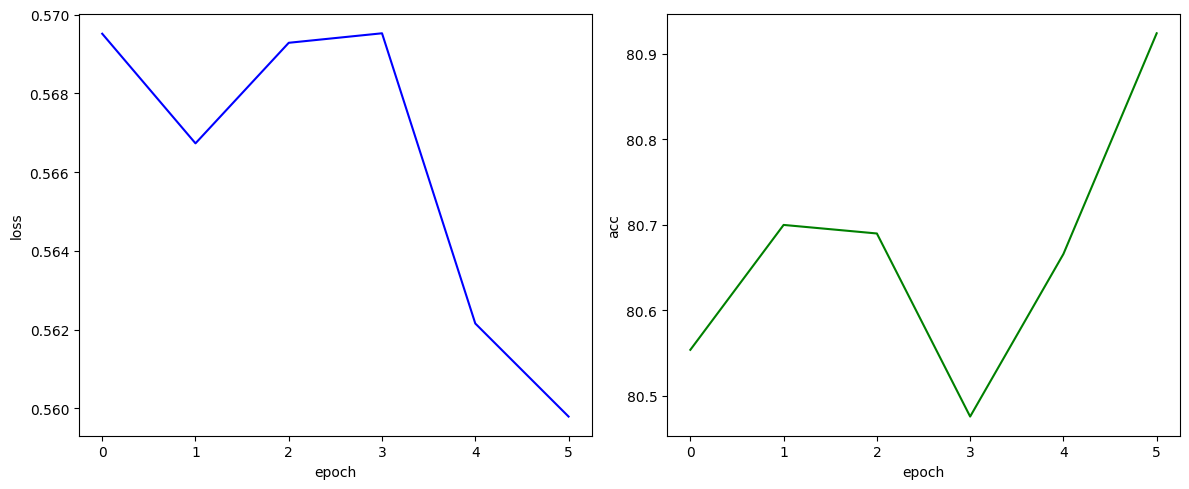

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))  # 创建12x5英寸的画布

# 子图1：损失曲线
plt.subplot(1, 2, 1)  # 1行2列的第1个子图
plt.ylabel("loss")
plt.xlabel("epoch")
plt.plot(train_losses, label='Train Loss', color='blue', linestyle='-')

# 子图2：准确率曲线
plt.subplot(1, 2, 2)
plt.ylabel("acc")
plt.xlabel("epoch")
plt.plot(train_accuracies, label='Train Acc', color='green', linestyle='-')
plt.tight_layout()  # 自动调整子图间距
plt.savefig('training_curves.png')  # 保存为PNG文件
plt.show()  # 显示图像

### 实际训练时如果发现：
* 训练损失持续下降但测试损失上升 → 过拟合
* 训练准确率明显高于测试准确率 → 需要加强正则化
* 曲线震荡剧烈 → 适当减小学习率

### 基础模型：约85-88%测试准确率
* 加入残差连接：提升至90-92%
* 使用ResNet-18架构：可达93-95%
### 要求：
* 将模型的改进在文档中进行介绍，要求不少于2000字
* 将模型训练时的loss和acc数据变化绘制折线图进行展示
* 要求测试集的准确率大于90%